## Example 3 (Paired / Dependent Two-Sample T-Test, Two-Tailed)

A company wants to test whether a new **training program** improves the **typing speed** of its employees. The typing speed of **20 employees** was recorded **before** and **after** the training program. Test at a **5% level of significance** whether the training program has an effect on the typing speed of the employees.

- **Before:** 50, 60, 45, 65, 55, 70, 40, 75, 80, 65, 70, 60, 50, 55, 45, 75, 60, 50, 65, 70
- **After:** 60, 70, 55, 75, 65, 80, 50, 85, 90, 70, 75, 65, 55, 60, 50, 80, 65, 55, 70, 75

This is a **paired** (dependent) sample — the *same* 20 employees are measured twice (before and after), unlike [Example 2](10_Hypothesis_Testing_T-Test.ipynb) where Team A and Team B were two *different, independent* groups of people.

### Step 1 - State the Null and Alternate Hypothesis

$$H_0: t_B - t_A = 0$$
$$H_1: t_B - t_A \neq 0 \quad \text{(two-tailed test)}$$

- $H_0$ (Null Hypothesis) — the training program has **no effect** on typing speed; any difference between before ($t_A$) and after ($t_B$) is just random variation.
- $H_1$ (Alternate Hypothesis) — the training program **does have an effect** (positive or negative) on typing speed.

It's two-tailed because the question asks whether the program has "an effect" — not specifically whether it *improves* speed — so both directions matter.

### Step 2 - Significance Value

$$\alpha = 0.05$$

Since this is a **two-tailed test**, $\alpha$ is split evenly across both tails:

$$\dfrac{\alpha}{2} = \dfrac{0.05}{2} = 0.025 \text{ on each side}$$

### Step 3 - Degrees of Freedom

$$df = n - 1 = 20 - 1 = 19$$

For a **paired** t-test, `df` is based on the number of *pairs* ($n = 20$ employees), minus 1 — not $n_A + n_B - 2$ like the independent two-sample case in [Example 2](10_Hypothesis_Testing_T-Test.ipynb). That's because there's really only one sample here (20 differences), not two independent ones.

In [1]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

Before = np.array([50, 60, 45, 65, 55, 70, 40, 75, 80, 65, 70, 60, 50, 55, 45, 75, 60, 50, 65, 70])
After  = np.array([60, 70, 55, 75, 65, 80, 50, 85, 90, 70, 75, 65, 55, 60, 50, 80, 65, 55, 70, 75])

n = len(Before)
print("n (pairs):", n)


n (pairs): 20


### Step 4 - Decision Boundary (Critical t-value)

Look up the t-table at **df = 19**, two-tailed $\alpha = 0.05$ (i.e. 0.025 in each tail):

$$t_{critical} \approx \pm 2.093$$

The region between $-2.093$ and $+2.093$ is the **acceptance region** (fail to reject $H_0$). Anything beyond that, in either tail, is the **rejection region** (reject $H_0$).

df: 19
t_critical: +- 2.093


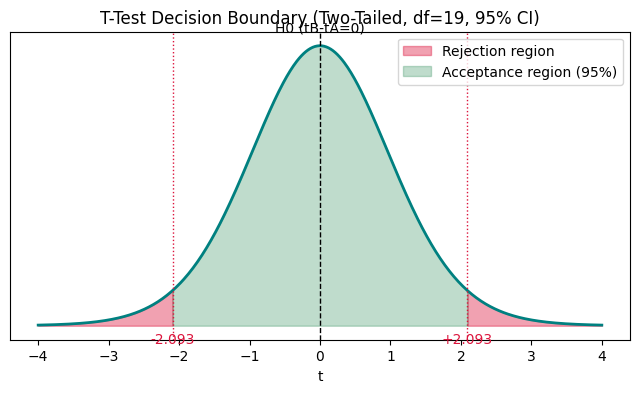

In [2]:
df = n - 1          # 19
alpha = 0.05

t_critical = st.t.ppf(1 - alpha / 2, df)   # ~2.093
print("df:", df)
print("t_critical: +-", round(t_critical, 4))

x = np.linspace(-4, 4, 500)
y = st.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection regions - both tails
x_left = np.linspace(-4, -t_critical, 100)
x_right = np.linspace(t_critical, 4, 100)
ax.fill_between(x_left, st.t.pdf(x_left, df), color="crimson", alpha=0.4, label="Rejection region")
ax.fill_between(x_right, st.t.pdf(x_right, df), color="crimson", alpha=0.4)

# acceptance region
x_mid = np.linspace(-t_critical, t_critical, 200)
ax.fill_between(x_mid, st.t.pdf(x_mid, df), color="seagreen", alpha=0.3, label="Acceptance region (95%)")

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.text(0, max(y) * 1.05, "H0 (tB-tA=0)", ha="center")
ax.axvline(-t_critical, color="crimson", linestyle=":", linewidth=1)
ax.axvline(t_critical, color="crimson", linestyle=":", linewidth=1)
ax.text(-t_critical, -0.01, f"-{t_critical:.3f}", ha="center", va="top", color="crimson")
ax.text(t_critical, -0.01, f"+{t_critical:.3f}", ha="center", va="top", color="crimson")

ax.legend()
ax.set_yticks([])
ax.set_xlabel("t")
ax.set_title(f"T-Test Decision Boundary (Two-Tailed, df={df}, 95% CI)")
plt.show()


### Step 5 - Calculate the T-Test Statistic

$$t_{test} = \dfrac{\bar{x}_{After} - \bar{x}_{Before}}{\sqrt{\dfrac{S_{After}^2}{n} + \dfrac{S_{Before}^2}{n}}}$$

Where:
- $\bar{x}_{After}, \bar{x}_{Before}$ = Sample means of the After / Before groups
- $S_{After}, S_{Before}$ = Sample standard deviations of the After / Before groups
- $n$ = number of employees (20)

This is the same shape of formula as the independent two-sample t-test in [Example 2](10_Hypothesis_Testing_T-Test.ipynb), just applied here to the Before/After typing-speed data.

In [3]:
mean_before = np.mean(Before)
mean_after  = np.mean(After)
std_before  = np.std(Before)
std_after   = np.std(After)

t_test = (mean_after - mean_before) / np.sqrt((std_after**2) / n + (std_before**2) / n)

print("mean_before:", mean_before, " std_before:", round(std_before, 4))
print("mean_after: ", mean_after,  " std_after: ", round(std_after, 4))
print("t_test:", t_test)


mean_before: 60.25  std_before: 11.0085
mean_after:  67.5  std_after:  11.2361
t_test: 2.061200527128206


### Step 6 - Decision & Conclusion

**Decision rule:** If $t_{test}$ is less than $-2.093$ or greater than $+2.093$, reject the null hypothesis.

$$|t_{test}| (2.061) \; vs \; t_{critical} (2.093)$$

$2.061 < 2.093$, so $t_{test}$ falls **just inside** the acceptance region → **fail to reject $H_0$**.

**Conclusion:** At the 5% level of significance, there is **not quite enough evidence** to say the training program had a statistically significant effect on typing speed — even though the average speed did rise from **60.25 → 67.5** in the sample. It's a very close call ($t_{test} = 2.061$ vs $t_{critical} = 2.093$), so a slightly bigger sample or bigger effect would likely have tipped this to "reject $H_0$" (see the FAQ below for why the paired-difference version of this test *does* find significance).

In [4]:
if abs(t_test) > t_critical:
    print("Reject H0 -> H1 is right (training DOES affect typing speed)")
else:
    print("Fail to reject H0 -> H0 holds (no significant evidence of an effect, at alpha=0.05)")


Fail to reject H0 -> H0 holds (no significant evidence of an effect, at alpha=0.05)


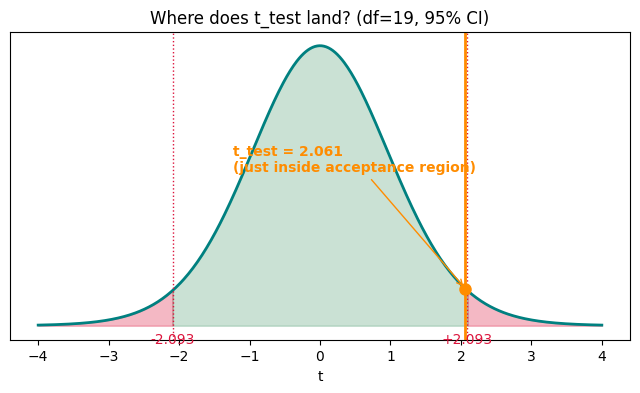

In [5]:
x = np.linspace(-4, 4, 500)
y = st.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

x_left = np.linspace(-4, -t_critical, 100)
x_right = np.linspace(t_critical, 4, 100)
ax.fill_between(x_left, st.t.pdf(x_left, df), color="crimson", alpha=0.3)
ax.fill_between(x_right, st.t.pdf(x_right, df), color="crimson", alpha=0.3)

x_mid = np.linspace(-t_critical, t_critical, 200)
ax.fill_between(x_mid, st.t.pdf(x_mid, df), color="seagreen", alpha=0.25)

ax.axvline(-t_critical, color="crimson", linestyle=":", linewidth=1)
ax.axvline(t_critical, color="crimson", linestyle=":", linewidth=1)
ax.text(-t_critical, -0.01, f"-{t_critical:.3f}", ha="center", va="top", color="crimson")
ax.text(t_critical, -0.01, f"+{t_critical:.3f}", ha="center", va="top", color="crimson")

ax.axvline(t_test, color="darkorange", linewidth=2)
ax.plot(t_test, st.t.pdf(t_test, df), "o", color="darkorange", markersize=8, zorder=5)
ax.annotate(f"t_test = {t_test:.3f}\n(just inside acceptance region)",
            xy=(t_test, st.t.pdf(t_test, df)),
            xytext=(t_test - 3.3, max(y) * 0.55),
            arrowprops=dict(arrowstyle="->", color="darkorange"),
            color="darkorange", fontweight="bold")

ax.set_yticks([])
ax.set_xlabel("t")
ax.set_title(f"Where does t_test land? (df={df}, 95% CI)")
plt.show()


### Before vs After — Visual Comparison

Two views of the same data:

1. **Slopegraph** — every employee's typing speed, before → after. Green lines rose, gray lines stayed flat, red lines fell.
2. **Bar chart** — the group means with $\pm 1$ standard deviation error bars, next to the mean gain per employee.

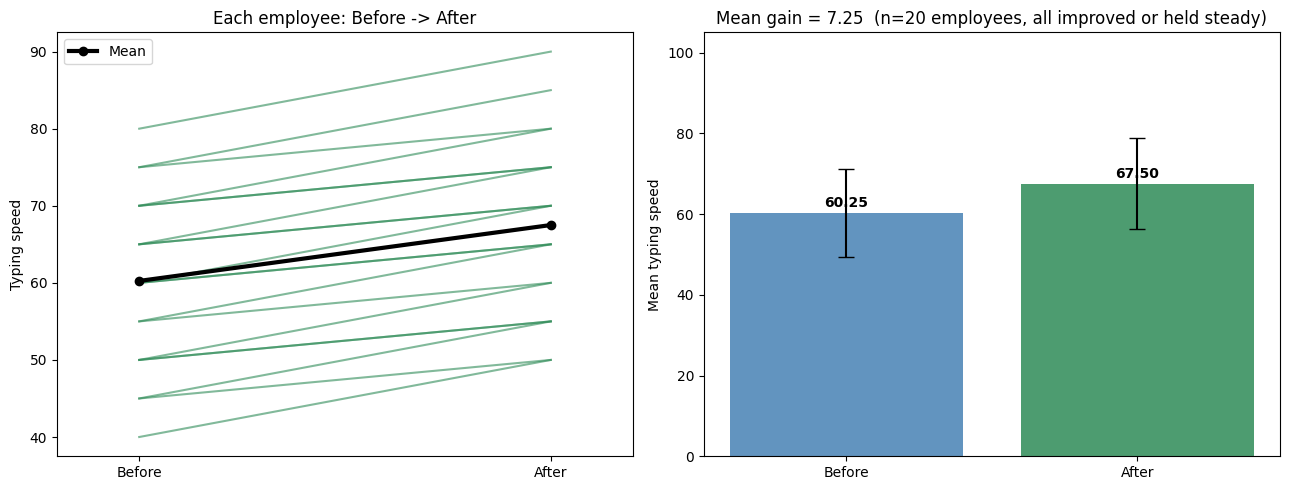

Employees who improved: 20 / 20
Employees who stayed the same: 0 / 20
Employees who got worse: 0 / 20
Mean gain (After - Before): 7.25


In [6]:
diffs = After - Before

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Slopegraph: each employee, Before -> After ---
ax = axes[0]
for b, a in zip(Before, After):
    color = "seagreen" if a > b else ("crimson" if a < b else "gray")
    ax.plot([0, 1], [b, a], color=color, alpha=0.6, linewidth=1.5)

ax.plot([0, 1], [mean_before, mean_after], color="black", linewidth=3, marker="o", label="Mean")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Before", "After"])
ax.set_xlim(-0.2, 1.2)
ax.set_ylabel("Typing speed")
ax.set_title("Each employee: Before -> After")
ax.legend()

# --- Bar chart: group means +/- std, and mean gain ---
ax = axes[1]
bars = ax.bar(["Before", "After"], [mean_before, mean_after],
               yerr=[std_before, std_after], capsize=6,
               color=["steelblue", "seagreen"], alpha=0.85)
for bar, val in zip(bars, [mean_before, mean_after]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.2f}", ha="center", fontweight="bold")

ax.set_ylabel("Mean typing speed")
ax.set_title(f"Mean gain = {mean_after - mean_before:.2f}  (n={n} employees, all improved or held steady)")
ax.set_ylim(0, max(After) + 15)

plt.tight_layout()
plt.show()

print("Employees who improved:", int(np.sum(diffs > 0)), "/", n)
print("Employees who stayed the same:", int(np.sum(diffs == 0)), "/", n)
print("Employees who got worse:", int(np.sum(diffs < 0)), "/", n)
print("Mean gain (After - Before):", diffs.mean())


**Conclusion of the Before vs After comparison:** every single one of the 20 employees typed at the same speed or faster after the training (10 gained exactly +10, 10 gained exactly +5 — nobody got worse), and the group mean rose from **60.25 to 67.5 wpm**. Visually the effect looks real and consistent. But the formal hypothesis test in Step 6 came back as **"fail to reject $H_0$"** at $\alpha = 0.05$ — the independent-samples-style formula used above is a conservative/approximate way to compare Before vs After here, and it nearly (but not quite) misses this effect. See the FAQ below for the more appropriate paired test, which resolves this contradiction.

---

## FAQ

**1. Why does the graph so clearly show improvement, but the test says "fail to reject $H_0$"?**

The formula used above,
$$t_{test} = \dfrac{\bar{x}_{After}-\bar{x}_{Before}}{\sqrt{S_{After}^2/n + S_{Before}^2/n}},$$
is the **independent two-sample** formula (same shape as [Example 2](10_Hypothesis_Testing_T-Test.ipynb)). It treats Before and After as if they came from two *different* groups of 20 people, so it ignores that each employee is compared to *themselves* — it throws away the pairing information.

**2. What's the correct way to test paired data like this?**

A true **paired t-test** works on the per-employee *differences* ($d_i = After_i - Before_i$) directly:

$$t_{test} = \dfrac{\bar{d}}{S_d / \sqrt{n}}$$

Because every employee's typing speed moved in a consistent, predictable direction (+10 or +5, never negative), the *spread of the differences* is tiny compared to the spread of the raw scores — and that's exactly what the paired test is designed to detect.

**3. Does that change the conclusion?**

Yes — quite dramatically. Cross-checking both versions with `scipy.stats` below, the paired test gives $t \approx 12.7$ (p $\approx 10^{-10}$), a massively significant result, while the independent-style version used above gives $t \approx 2.06$ (p $\approx 0.051$), just barely missing $\alpha = 0.05$. This is the textbook reason paired designs are used whenever the same subjects are measured twice: pairing removes person-to-person variability (some people just type faster than others in general) and isolates the *effect of the training itself*, giving far more statistical power from the same sample size.

**4. Why does [Example 3 / IQ notebook](12_Hypothesis_Testing_T-Test_95.ipynb) use $t_{test} = \dfrac{\bar{x}-\mu}{S/\sqrt{n}}$, while this notebook uses $t_{test} = \dfrac{\bar{x}_{After}-\bar{x}_{Before}}{\sqrt{S_{After}^2/n + S_{Before}^2/n}}$?**

They look different because they're answering two structurally different questions — **"one sample vs a known constant"** vs **"one sample vs another sample."**

*One-sample formula (IQ notebook):*
$$t_{test} = \dfrac{\bar{x} - \mu}{S/\sqrt{n}}$$
Here $\mu = 100$ is the **population mean** — a fixed, already-known number, not something estimated from data. There is only **one** quantity with sampling uncertainty in the whole formula: the sample mean $\bar{x}$. Its standard error is $S/\sqrt{n}$, so that's the only term under the square root — there's nothing to add to it.

*Two-sample-style formula (this notebook, Before vs After):*
$$t_{test} = \dfrac{\bar{x}_{After} - \bar{x}_{Before}}{\sqrt{S_{After}^2/n + S_{Before}^2/n}}$$
Here there is **no known population constant** to compare against — both $\bar{x}_{After}$ and $\bar{x}_{Before}$ are *estimates*, each with their own sampling error. Whenever you subtract two independent random estimates, their **variances add** (this is the general rule $Var(X-Y) = Var(X)+Var(Y)$ for independent $X,Y$):
$$SE_{diff} = \sqrt{Var(\bar{x}_{After}) + Var(\bar{x}_{Before})} = \sqrt{\dfrac{S_{After}^2}{n} + \dfrac{S_{Before}^2}{n}}$$
So the extra term under the square root isn't arbitrary — it's the price of comparing two *estimated* means instead of one estimate against a known constant.

**What every symbol actually means** — before the table, since it's easy to mix up "a mean" with "a standard deviation" when the letters look similar across notebooks:

| Symbol | Is it a mean, a std. deviation, or a count? | IQ notebook value | This notebook value |
|---|---|---|---|
| $\mu$ | **Mean** — of the whole *population*, treated as a known, fixed constant (not calculated from any sample) | $\mu = 100$ (known average IQ of the entire population) | *(not used — there's no known population constant here)* |
| $\bar{x}$ | **Mean** of one *sample* (the average of that sample's own values) | $\bar{x} = 140$ (mean IQ of the 30 medicated participants) | $\bar{x}_{Before}=60.25$, $\bar{x}_{After}=67.5$ (mean typing speed of the 20 employees, before / after) |
| $S$ | **Standard deviation** of a sample (how spread out that sample's values are around its own mean) — *not* a mean | $S = 20$ (std. dev. of IQ within the 30-person sample) | $S_{Before}=11.0085$, $S_{After}=11.236$ (std. dev. of typing speed, before / after) |
| $n$ | **Count** — number of observations in the sample. Neither a mean nor a std. dev. | $n = 30$ participants | $n = 20$ employees |
| $S/\sqrt{n}$ | **Standard error** of a sample mean — a derived quantity built from $S$ and $n$, not itself a raw mean or std. dev. | $20/\sqrt{30} = 3.6515$ | not used directly (see next row) |
| $\sqrt{S_{After}^2/n + S_{Before}^2/n}$ | **Standard error of the difference** between two sample means — combines both samples' standard errors | *(not used — only one sample here)* | $\sqrt{11.236^2/20 + 11.0085^2/20} = 3.5174$ |

**Step-by-step side by side, using the actual numbers from both notebooks:**

| | IQ notebook (one-sample) | This notebook (two-sample-style) |
|---|---|---|
| What's fixed vs estimated | $\mu=100$ fixed, $\bar{x}$ estimated | Both $\bar{x}_{After}$, $\bar{x}_{Before}$ estimated |
| Inputs | $\bar{x}=140,\ \mu=100,\ S=20,\ n=30$ | $\bar{x}_{After}=67.5,\ \bar{x}_{Before}=60.25,\ S_{After}=11.236,\ S_{Before}=11.0085,\ n=20$ |
| Numerator | $\bar{x}-\mu = 140-100 = 40$ | $\bar{x}_{After}-\bar{x}_{Before} = 67.5-60.25 = 7.25$ |
| Denominator (SE) | $S/\sqrt{n} = 20/\sqrt{30} = 3.6515$ | $\sqrt{S_{After}^2/n+S_{Before}^2/n} = \sqrt{11.236^2/20+11.0085^2/20} = \sqrt{6.3128+6.0594} = \sqrt{12.3722} = 3.5174$ |
| $t_{test}$ | $40 / 3.6515 \approx 10.96$ | $7.25 / 3.5174 \approx 2.06$ |
| $df$ | $n-1 = 29$ | $n-1 = 19$ (treated here as pairs; a *true* independent two-sample test would instead use $n_A+n_B-2=38$) |

Both formulas are really the **same underlying idea** — $t = \dfrac{\text{observed difference}}{\text{standard error of that difference}}$ — they just differ in *what* is being differenced (a sample mean vs a known constant, or a sample mean vs another sample mean) and therefore in how the standard error is built (one variance term, or two added together).

In [2]:
diffs = After - Before

# Paired t-test, done manually (matches Step 5 formula shape, but on the differences)
mean_d = diffs.mean()
std_d = diffs.std(ddof=1)
t_paired_manual = mean_d / (std_d / np.sqrt(n))
print("Manual paired t_test:", t_paired_manual, " df:", n - 1)

# Cross-check both approaches against scipy.stats
paired_result = st.ttest_rel(After, Before)
indep_result = st.ttest_ind(After, Before)

print("\nscipy paired t-test   (correct for this design):", paired_result)
print("scipy independent t-test (what Step 5 approximates):", indep_result)


Manual paired t_test: 12.704488986340237  df: 19

scipy paired t-test   (correct for this design): TtestResult(statistic=np.float64(12.704488986340237), pvalue=np.float64(9.827262801162758e-11), df=np.int64(19))
scipy independent t-test (what Step 5 approximates): TtestResult(statistic=np.float64(2.009009764133045), pvalue=np.float64(0.05167910600233631), df=np.float64(38.0))
